# 01 Residual Bootstrap -- CI Band Visualization

End-to-end pipeline: ingest Peace River discharge data, generate a 200-member residual bootstrap ensemble (IID or AR(1) path selected by Durbin-Watson diagnostic), export CSVs, and render a 5th-95th percentile CI band with observation scatter and WAM model line.

**Run this notebook from the repo root directory:** `jupyter notebook`

This notebook is the template pattern for Phases 3-5 (GLUE, EnKF, LPU).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from red_tide_reanalysis.ingestion import load_observations, load_wam_model, align_obs_model
from red_tide_reanalysis.bootstrap import ResidualBootstrapMethod
from red_tide_reanalysis.writers import write_ensemble_csv, write_stats_csv

## 1. Load and Align Data

In [2]:
obs_raw = load_observations("../Observation_Data/Observed_flow_ARCADIA_FL.csv")
wam_raw = load_wam_model("../Synthetic_Model_Data/Station 02296750 (ARCADIA)_reach000084_83.csv")
obs, model = align_obs_model(obs_raw, wam_raw)
print(f"Aligned series: {len(obs)} timesteps, {obs.index[0].date()} to {obs.index[-1].date()}")

Aligned series: 9131 timesteps, 1999-01-01 to 2023-12-31


## 2. Run Residual Bootstrap

In [3]:
method = ResidualBootstrapMethod(station_id="02296750_peace_river")
result = method.run(obs=obs, model=model, n_members=200, seed=42)
print(f"Ensemble shape: {result.members.shape}")

Ensemble shape: (200, 9131)


## 3. Durbin-Watson Diagnostic

The Durbin-Watson statistic measures autocorrelation in the model residuals.
- DW < 1.5: positive autocorrelation detected -> AR(1) bootstrap path
- DW >= 1.5: residuals treated as IID -> IID bootstrap path

In [4]:
dw_val = result.config["dw"]
path_sel = result.config["path"]
print(f"Durbin-Watson statistic: {dw_val:.4f}")
print(f"Selected bootstrap path: {path_sel.upper()}")
if path_sel == "ar1":
    print("  -> Positive autocorrelation detected in residuals")
else:
    print("  -> Residuals treated as IID (no significant autocorrelation)")

Durbin-Watson statistic: 0.1444
Selected bootstrap path: AR1
  -> Positive autocorrelation detected in residuals


## 4. Export CSVs

In [5]:
output_dir = Path("data/outputs")
ens_path = write_ensemble_csv(result, output_dir / "ensembles")
stats_path = write_stats_csv(result, output_dir / "stats")
print(f"Ensemble CSV: {ens_path}")
print(f"Stats CSV:    {stats_path}")

Ensemble CSV: data\outputs\ensembles\bootstrap_02296750_peace_river_discharge_members.csv
Stats CSV:    data\outputs\stats\bootstrap_02296750_peace_river_discharge_stats.csv


## 5. CI Band Visualization

Single shaded band showing the 5th-95th percentile of the bootstrap ensemble.
Observations plotted as scatter points; WAM model output as a continuous line.

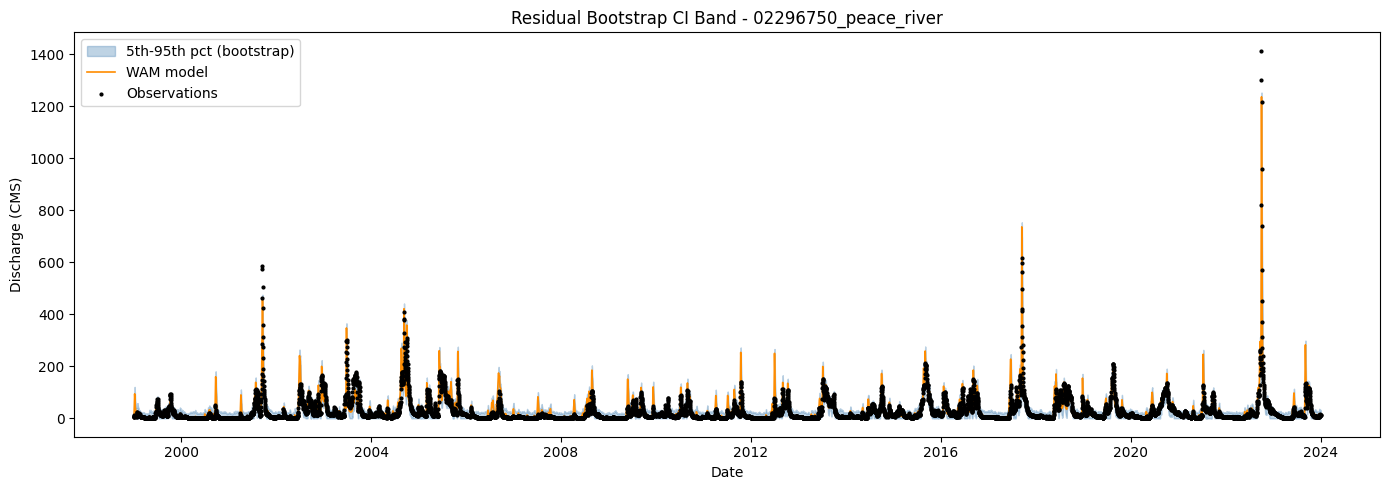

In [6]:
q05 = np.percentile(result.members, 5, axis=0)
q95 = np.percentile(result.members, 95, axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(result.time_index, q05, q95, alpha=0.35, color="steelblue",
                label="5th-95th pct (bootstrap)")
ax.plot(result.time_index, result.model_output.values,
        color="darkorange", linewidth=1.2, label="WAM model")
ax.scatter(result.time_index, result.observations.values,
           s=4, color="black", label="Observations", zorder=3)
ax.set_xlabel("Date")
ax.set_ylabel("Discharge (CMS)")
ax.set_title(f"Residual Bootstrap CI Band - {result.station_id}")
ax.legend()
plt.tight_layout()
plt.show()